In [1]:
library("SingleR")

载入需要的程序包：SummarizedExperiment

载入需要的程序包：MatrixGenerics

载入需要的程序包：matrixStats


载入程序包：‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges, rowRanks,
    rowSdDiffs, rowSds, rowSums2, rowTabulates, rowV

In [2]:
library(celldex)
library(Seurat)
library(pheatmap)


载入程序包：‘celldex’


The following objects are masked from ‘package:SingleR’:

    BlueprintEncodeData, DatabaseImmuneCellExpressionData,
    HumanPrimaryCellAtlasData, ImmGenData, MonacoImmuneData,
    MouseRNAseqData, NovershternHematopoieticData


载入需要的程序包：SeuratObject

载入需要的程序包：sp


载入程序包：‘sp’


The following object is masked from ‘package:IRanges’:

    %over%



载入程序包：‘SeuratObject’


The following object is masked from ‘package:SummarizedExperiment’:

    Assays


The following object is masked from ‘package:GenomicRanges’:

    intersect


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following object is masked from ‘package:IRanges’:

    intersect


The following object is masked from ‘package:S4Vectors’:

    intersect


The following object is masked from ‘package:BiocGenerics’:

    intersect


The following objects are masked from ‘package:base’:

    intersect, t



载入程序包：‘Seurat’


The following object is masked from ‘package:SummarizedE

# human

In [3]:
##下载注释数据库
hpca.se <- HumanPrimaryCellAtlasData()
hpca.se

class: SummarizedExperiment 
dim: 19363 713 
metadata(0):
assays(1): logcounts
rownames(19363): A1BG A1BG-AS1 ... ZZEF1 ZZZ3
rowData names(0):
colnames(713): GSM112490 GSM112491 ... GSM92233 GSM92234
colData names(3): label.main label.fine label.ont

In [5]:
unique(hpca.se$label.main)

[1] "DC"                   "Smooth_muscle_cells"  "Epithelial_cells"    
 [4] "B_cell"               "Neutrophils"          "T_cells"             
 [7] "Monocyte"             "Erythroblast"         "BM & Prog."          
[10] "Endothelial_cells"    "Gametocytes"          "Neurons"             
[13] "Keratinocytes"        "HSC_-G-CSF"           "Macrophage"          
[16] "NK_cell"              "Embryonic_stem_cells" "Tissue_stem_cells"   
[19] "Chondrocytes"         "Osteoblasts"          "BM"                  
[22] "Platelets"            "Fibroblasts"          "iPS_cells"           
[25] "Hepatocytes"          "MSC"                  "Neuroepithelial_cell"
[28] "Astrocyte"            "HSC_CD34+"            "CMP"                 
[31] "GMP"                  "MEP"                  "Myelocyte"           
[34] "Pre-B_cell_CD34-"     "Pro-B_cell_CD34+"     "Pro-Myelocyte"

In [ ]:
#直接load下载好的数据库
load("HumanPrimaryCellAtlas_hpca.se_human.RData")
load("BlueprintEncode_bpe.se_human.RData")

In [8]:
human <- readRDS("/public/workspace/lhpeng/gwork/deg/human_sp_annot.rds")

In [10]:
assay_data <- GetAssayData(human, layer = "data")

In [13]:
human@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,species,percent.mt,sample,RNA_snn_res.0.2,seurat_clusters,cell_type
,<fct>,<dbl>,<int>,<chr>,<dbl>,<chr>,<fct>,<fct>,<fct>
AAACCTGAGAGGTAGA-1,human,2957,1310,human,7.372337,1,2,2,Neutrophil
AAACCTGAGCAAATCA-1,human,2434,1224,human,6.162695,1,2,2,Neutrophil
AAACCTGAGCAGACTG-1,human,6834,1850,human,6.599356,1,1,1,B cell
AAACCTGAGCGATTCT-1,human,3115,1384,human,8.089888,1,0,0,T cell
AAACCTGAGCTGCAAG-1,human,2710,1140,human,5.904059,1,0,0,T cell
AAACCTGAGGAGTACC-1,human,8425,2670,human,7.240356,1,0,0,T cell
AAACCTGAGGAGTAGA-1,human,3706,1551,human,7.447383,1,0,0,T cell
AAACCTGAGGATATAC-1,human,3631,1442,human,8.620215,1,3,3,T cell
AAACCTGAGGCCATAG-1,human,750,416,human,9.333333,1,0,0,T cell


In [15]:
#SingleR注释
pred <- SingleR(test = assay_data,       #输入表达矩阵
                ref = hpca.se,                                #参考数据
                labels = hpca.se$label.fine,                  #标签列
                clusters = human$seurat_clusters)                         #注释类型，按照cluster还是按照cell进行注释

Warning message in SingleR(test = assay_data, ref = hpca.se, labels = hpca.se$label.fine, :
“'method="cluster"' is no longer necessary when 'cluster=' is specified”


In [16]:
#保存SingleR注释结果,需要根据自己情况设置文件位置
write.table(pred,"Singler_human.xls",sep='\t',quote = F)

In [17]:
head(pred)

DataFrame with 6 rows and 4 columns
                          scores                 labels delta.next
                        <matrix>            <character>  <numeric>
0 0.297741:0.595207:0.574405:...            T_cell:CD8+  0.0668261
1 0.301885:0.704035:0.677956:...          B_cell:Memory  0.0989499
2 0.307297:0.594748:0.570942:...            NK_cell:IL2  0.0587745
3 0.307119:0.598394:0.571214:... T_cell:CD4+_effector..  0.0503202
4 0.339161:0.623892:0.686743:...     B_cell:Plasma_cell  0.1403227
5 0.274655:0.676471:0.617003:...            T_cell:CD8+  0.1323762
           pruned.labels
             <character>
0            T_cell:CD8+
1          B_cell:Memory
2            NK_cell:IL2
3 T_cell:CD4+_effector..
4     B_cell:Plasma_cell
5            T_cell:CD8+

In [19]:
print(data.frame(
  clster = 0:7,
  cell_type = pred$labels
))

  clster                              cell_type
1      0                            T_cell:CD8+
2      1                          B_cell:Memory
3      2                            NK_cell:IL2
4      3            T_cell:CD4+_effector_memory
5      4                     B_cell:Plasma_cell
6      5                            T_cell:CD8+
7      6                           B_cell:Naive
8      7 Macrophage:monocyte-derived:M-CSF/IFNg


In [36]:
human$SingleR_annot <- pred$labels[ match(human$seurat_clusters, levels(human$seurat_clusters)) ]

In [37]:
human$cell_type_singler <- as.character(human$SingleR_annot)

In [38]:
human$cell_type_singler <- factor(human$cell_type_singler)

In [39]:
table(human$cell_type, human$cell_type_singler)

             
              B_cell:Memory B_cell:Naive B_cell:Plasma_cell
  T cell                  0            0                  0
  B cell               3259          617                  0
  Neutrophil              0            0                  0
  Plasma cell             0            0                745
  Macrophage              0            0                  0
             
              Macrophage:monocyte-derived:M-CSF/IFNg NK_cell:IL2
  T cell                                           0           0
  B cell                                           0           0
  Neutrophil                                       0        3140
  Plasma cell                                      0           0
  Macrophage                                     229           0
             
              T_cell:CD4+_effector_memory T_cell:CD8+
  T cell                             2125        3281
  B cell                                0         719
  Neutrophil                            0     

In [25]:
library("ggplot2")

In [41]:
p1 <- DimPlot(
  human,
  group.by = "cell_type",    # 用你注释好的列
  label = TRUE,              # 显示标签
  repel = TRUE,              # 标签不重叠
  label.size = 6,            # 标签大小
  pt.size = 0.6              # 点大小
) +
  ggtitle("Cell Types") +
  theme(
    plot.title = element_text(hjust = 0.5, size=16),
    legend.position = "none" # 不显示图例（更干净）
  )

In [42]:
p2 <- DimPlot(
  human,
  group.by = "cell_type_singler",    # 用你最终注释好的列
  label = TRUE,              # 显示标签
  repel = TRUE,              # 标签不重叠
  label.size = 6,            # 标签大小
  pt.size = 0.6              # 点大小
) +
  ggtitle("Cell Types(SingleR Annotation)") +
  theme(
    plot.title = element_text(hjust = 0.5, size=16),
    legend.position = "none" # 不显示图例（更干净）
  )

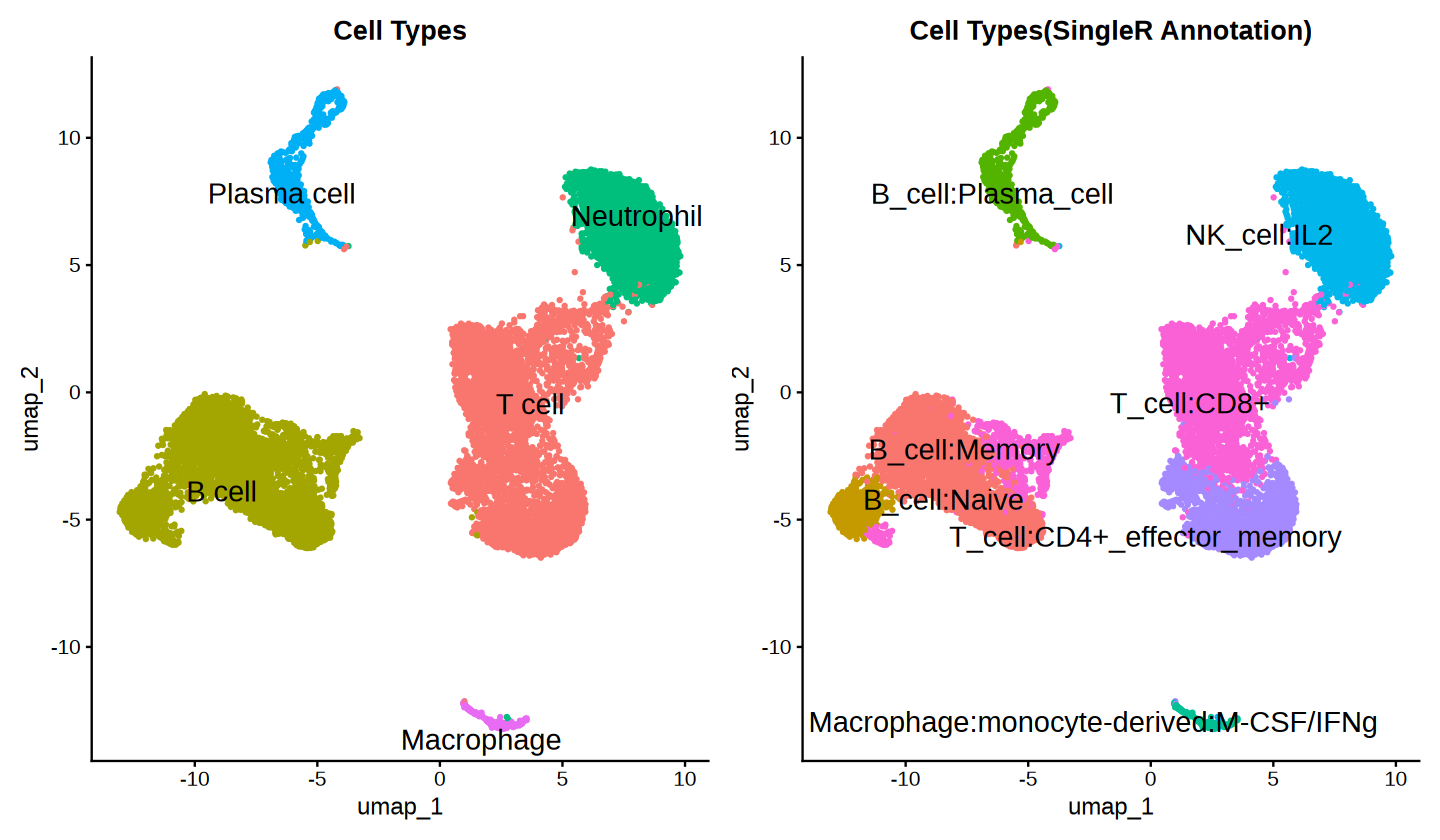

In [63]:
options(repr.plot.width=12, repr.plot.height=7)
p1 + p2
ggsave("human_cell_annotation_compare.svg", width = 12, height = 7)

# mouse

In [47]:
# 使用内置参考
hpca.se <- celldex::ImmGenData()
hpca.se

class: SummarizedExperiment 
dim: 22134 830 
metadata(0):
assays(1): logcounts
rownames(22134): Zglp1 Vmn2r65 ... Tiparp Kdm1a
rowData names(0):
colnames(830):
  GSM1136119_EA07068_260297_MOGENE-1_0-ST-V1_MF.11C-11B+.LU_1.CEL
  GSM1136120_EA07068_260298_MOGENE-1_0-ST-V1_MF.11C-11B+.LU_2.CEL ...
  GSM920654_EA07068_201214_MOGENE-1_0-ST-V1_TGD.VG4+24ALO.E17.TH_1.CEL
  GSM920655_EA07068_201215_MOGENE-1_0-ST-V1_TGD.VG4+24ALO.E17.TH_2.CEL
colData names(3): label.main label.fine label.ont

In [50]:
mouse <- readRDS("/public/workspace/lhpeng/gwork/deg/mouse_sp_annot.rds")
assay_data <- GetAssayData(mouse, layer = "data")

In [51]:
#SingleR注释
pred <- SingleR(test = assay_data,       #输入表达矩阵
                ref = hpca.se,                                #参考数据
                labels = hpca.se$label.fine,                  #标签列
                clusters = mouse$seurat_clusters)                         #注释类型，按照cluster还是按照cell进行注释

In [55]:
write.table(pred,"Singler_mouse.xls",sep='\t',quote = F)

In [56]:
print(data.frame(
  clster = 0:8,
  cell_type = pred$labels
))

  clster             cell_type
1      0        B cells (B.T3)
2      1 T cells (T.CD4TESTCJ)
3      2      T cells (T.8Nve)
4      3      T cells (T.8Mem)
5      4        B cells (B.T3)
6      5  NK cells (NK.DAP10-)
7      6 Monocytes (MO.6C-II+)
8      7    B cells (proB.FrA)
9      8        DC (DC.PDC.8+)


In [57]:
mouse$SingleR_annot <- pred$labels[ match(mouse$seurat_clusters, levels(mouse$seurat_clusters)) ]

mouse$cell_type_singler <- as.character(mouse$SingleR_annot)

mouse$cell_type_singler <- factor(mouse$cell_type_singler)

table(mouse$cell_type, mouse$cell_type_singler)

             
              B cells (B.T3) B cells (proB.FrA) DC (DC.PDC.8+)
  Neutrophil               0                261              0
  B cell                6499                  0              0
  T cell                   0                  0              0
  NK cell                  0                  0              0
  Macrophage               0                  0              0
  Plasma cell              0                  0             48
             
              Monocytes (MO.6C-II+) NK cells (NK.DAP10-) T cells (T.8Mem)
  Neutrophil                      0                    0                0
  B cell                          0                    0                0
  T cell                          0                    0             1563
  NK cell                         0                  461                0
  Macrophage                    346                    0                0
  Plasma cell                     0                    0                0
             


       B cells (B.T3)    B cells (proB.FrA)        DC (DC.PDC.8+) 
                    2                     1                     1 
Monocytes (MO.6C-II+)  NK cells (NK.DAP10-)      T cells (T.8Mem) 
                    1                     1                     1 
     T cells (T.8Nve) T cells (T.CD4TESTCJ) 
                    1                     1 

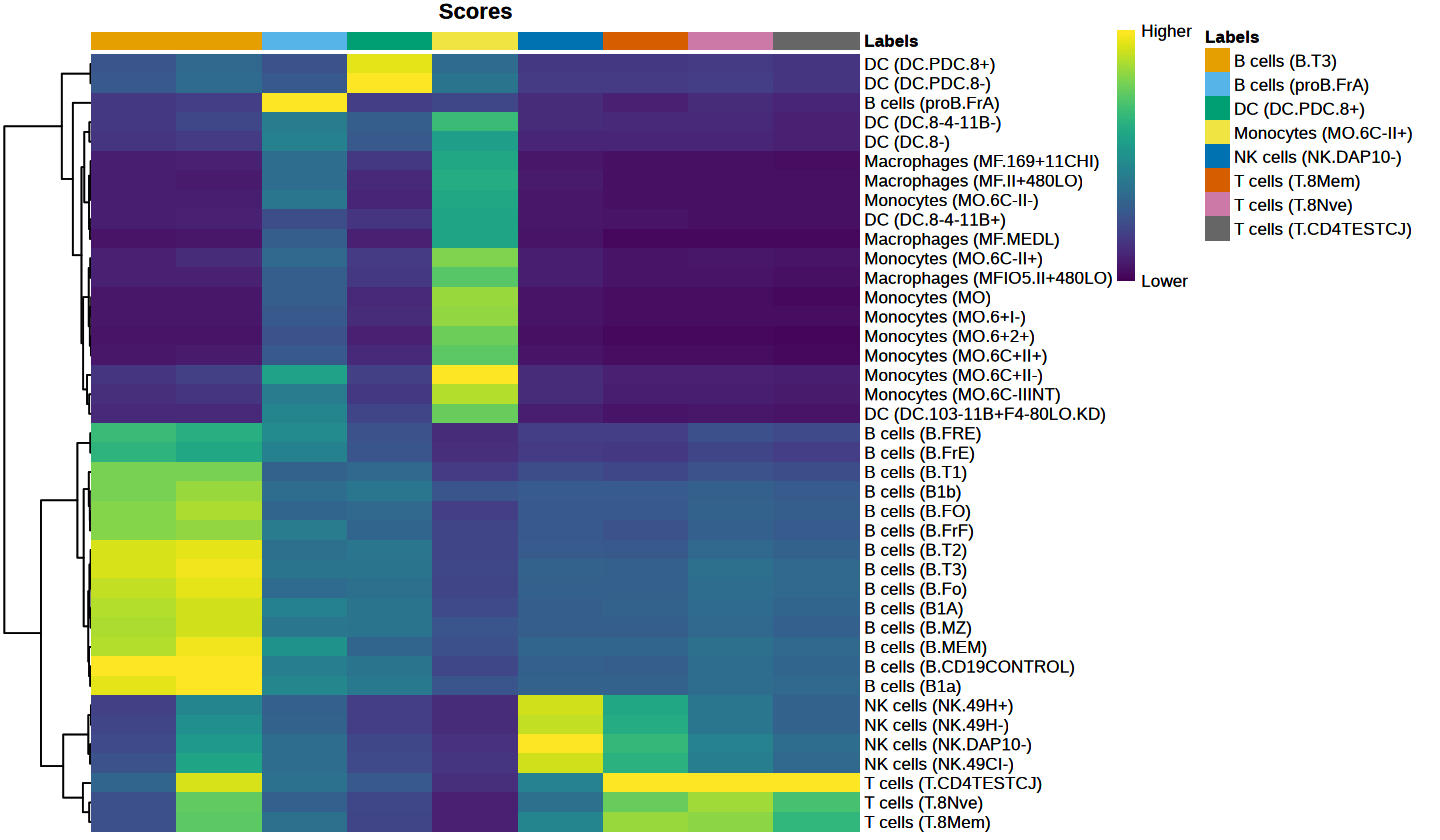

In [58]:
#看一下预测的结果
table(pred$labels)

# 看一下预测标签的置信度（右图）
plotScoreHeatmap(pred)

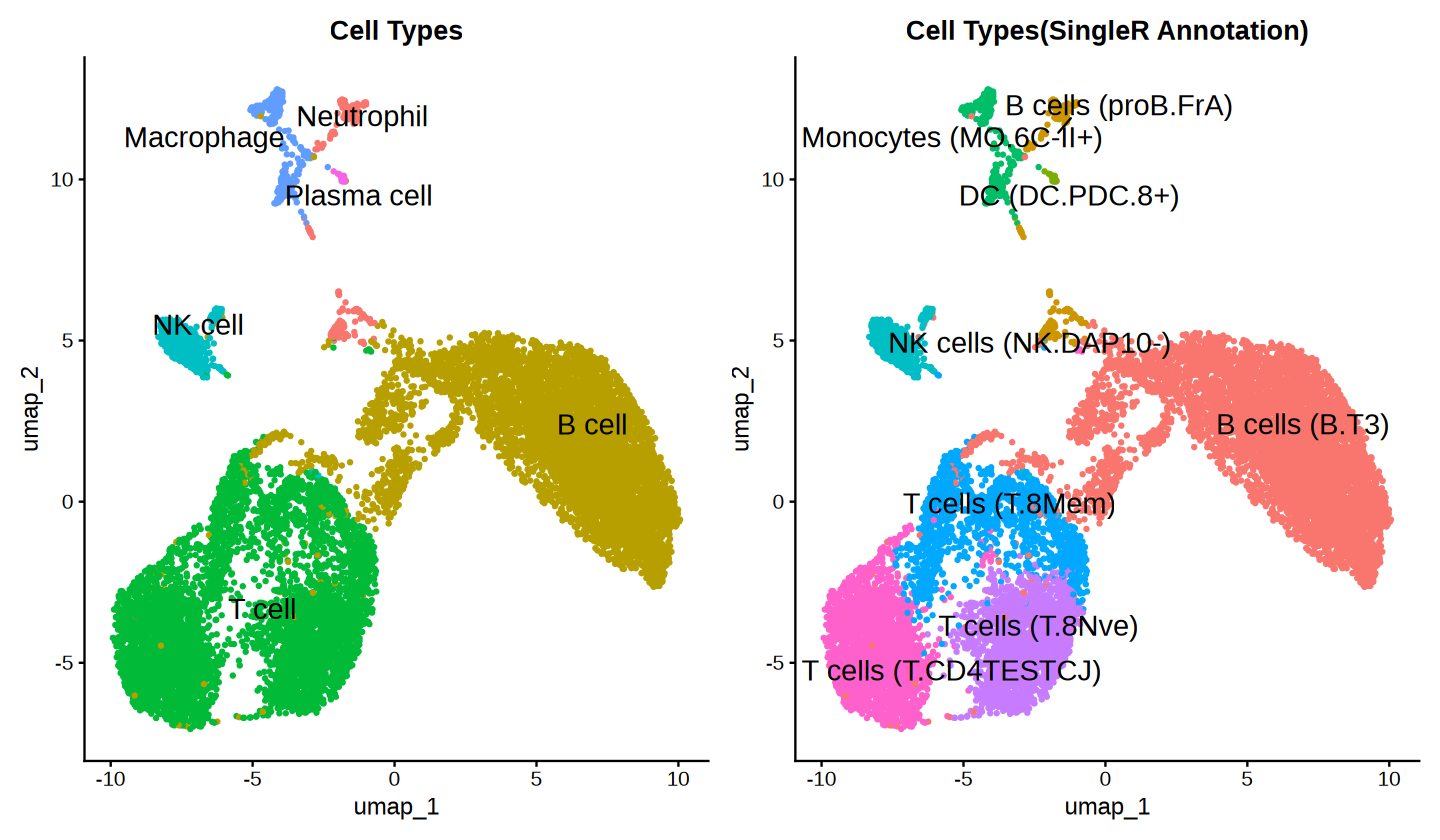

In [59]:
p3 <- DimPlot(
  mouse,
  group.by = "cell_type",    # 用你注释好的列
  label = TRUE,              # 显示标签
  repel = TRUE,              # 标签不重叠
  label.size = 6,            # 标签大小
  pt.size = 0.6              # 点大小
) +
  ggtitle("Cell Types") +
  theme(
    plot.title = element_text(hjust = 0.5, size=16),
    legend.position = "none" # 不显示图例（更干净）
  )

p4 <- DimPlot(
  mouse,
  group.by = "cell_type_singler",    # 用你最终注释好的列
  label = TRUE,              # 显示标签
  repel = TRUE,              # 标签不重叠
  label.size = 6,            # 标签大小
  pt.size = 0.6              # 点大小
) +
  ggtitle("Cell Types(SingleR Annotation)") +
  theme(
    plot.title = element_text(hjust = 0.5, size=16),
    legend.position = "none" # 不显示图例（更干净）
  )

options(repr.plot.width=12, repr.plot.height=7)
p3 + p4

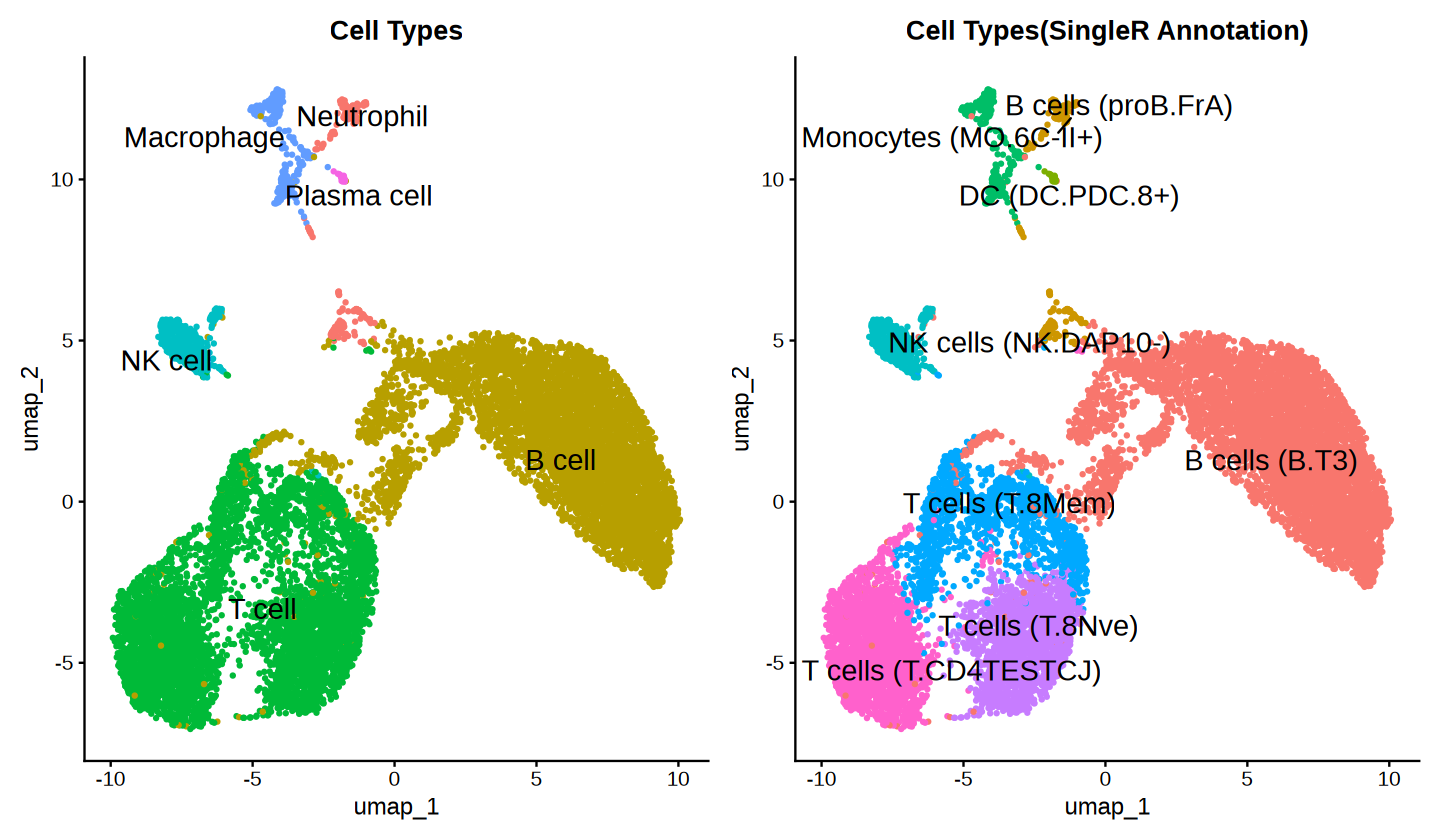

In [91]:
options(repr.plot.width=12, repr.plot.height=7)
p3 + p4
ggsave("mouse_cell_annotation_compare.svg", width = 12, height = 7)

In [60]:
# 保存处理好的Seurat对象，供后续整合分析使用
saveRDS(human, file = "human_sp_singler.rds")
saveRDS(mouse, file = "mouse_sp_singler.rds")

# 巨噬细胞亚群

In [64]:
mac_seurat <- subset(human, cell_type %in% c("Macrophage"))

In [65]:
mac_seurat <- NormalizeData(mac_seurat)
mac_seurat <- FindVariableFeatures(mac_seurat, nfeatures = 2000)
mac_seurat <- ScaleData(mac_seurat)
mac_seurat <- RunPCA(mac_seurat, npcs = 50)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”
PC_ 1 
Positive:  WSB1, NEAT1, FGD2, ABCA1, FRMD4B, MERTK, PDK4, NABP1, DAPK1, DST 
	   ATG16L2, PNISR, FRMD4A, VCAM1, RSRP1, ZEB2, SAT1, KLF6, MALAT1, ABCC5 
	   PARP14, NFKBIZ, NDST3, SAMSN1, SLC1A3, DUSP1, RGL3, LILRB2, XIST, UTRN 
Negative:  RPL10, EEF1A1, RPS23, RPS12, RPS8, RPS3A, RPS19, RPS14, RPS24, RPL6 
	   RPS3, RPS27, RPL8, RPL18A, RPL7A, RPLP0, RPS18, RPL18, RPS6, RPLP2 
	   RPL23A, RPS5, EEF1B2, RPL3, RPL5, RPSA, RPS21, RPL4, RPS2, ACTB 
PC_ 2 
Positive:  APOE, SLC40A1, HMOX1, SAT1, CST3, IGLV1-51, LIPA, MAFB, CALHM6, CTSC 
	   IGKV4-1, CSF1R, EBI3, CD74, VCAM1, KCNMA1, S100A11, MCOLN1, LGMN, IL18 
	   IGHV6-1, CCL24, CD38, IGLV2-14, ATP1B1, SLC7A7, CTSL, RAB20, NR1H3, MRC1 
Negative:  TRAF3IP3, LSP1, PTPRCAP, FLNA, BTG1, GZMA, PRF1, CD99, CST7, KLRD1 
	   CCL5, TXNIP, S100A6, C

In [66]:
mac_seurat <- FindNeighbors(mac_seurat, dims = 1:15)
mac_seurat <- FindClusters(mac_seurat, resolution = 0.5)
mac_seurat <- RunUMAP(mac_seurat, dims = 1:15)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 229
Number of edges: 6904

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7570
Number of communities: 3
Elapsed time: 0 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
00:38:37 UMAP embedding parameters a = 0.9922 b = 1.112

00:38:37 Read 229 rows and found 15 numeric columns

00:38:37 Using Annoy for neighbor search, n_neighbors = 30

00:38:37 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

00:38:37 Writing NN index file to temp file /tmp/RtmpAD7kps/file2b16326ed95bf

00:38:37 Searching Annoy index using 1 thread, search_k = 3000

00:38:38 Annoy recall = 100%

00:38:38 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors =

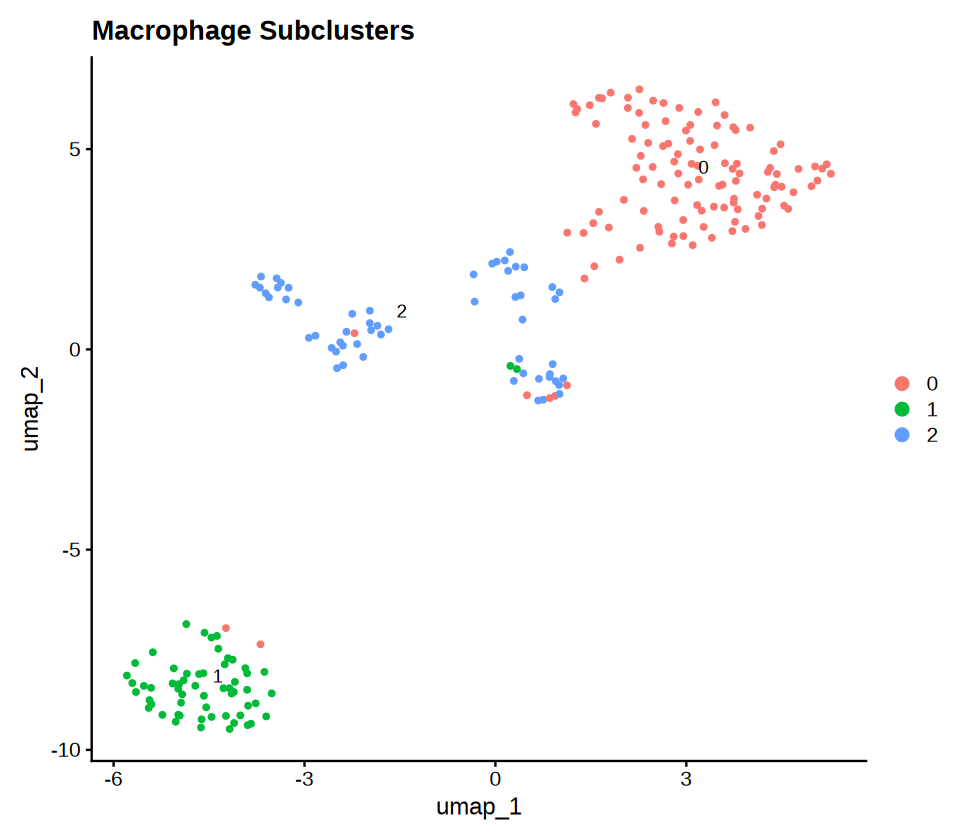

In [68]:
options(repr.plot.width=8, repr.plot.height=7)
DimPlot(mac_seurat, label = TRUE, repel = TRUE) + ggtitle("Macrophage Subclusters")

Warning message:
“Scaling data with a low number of groups may produce misleading results”


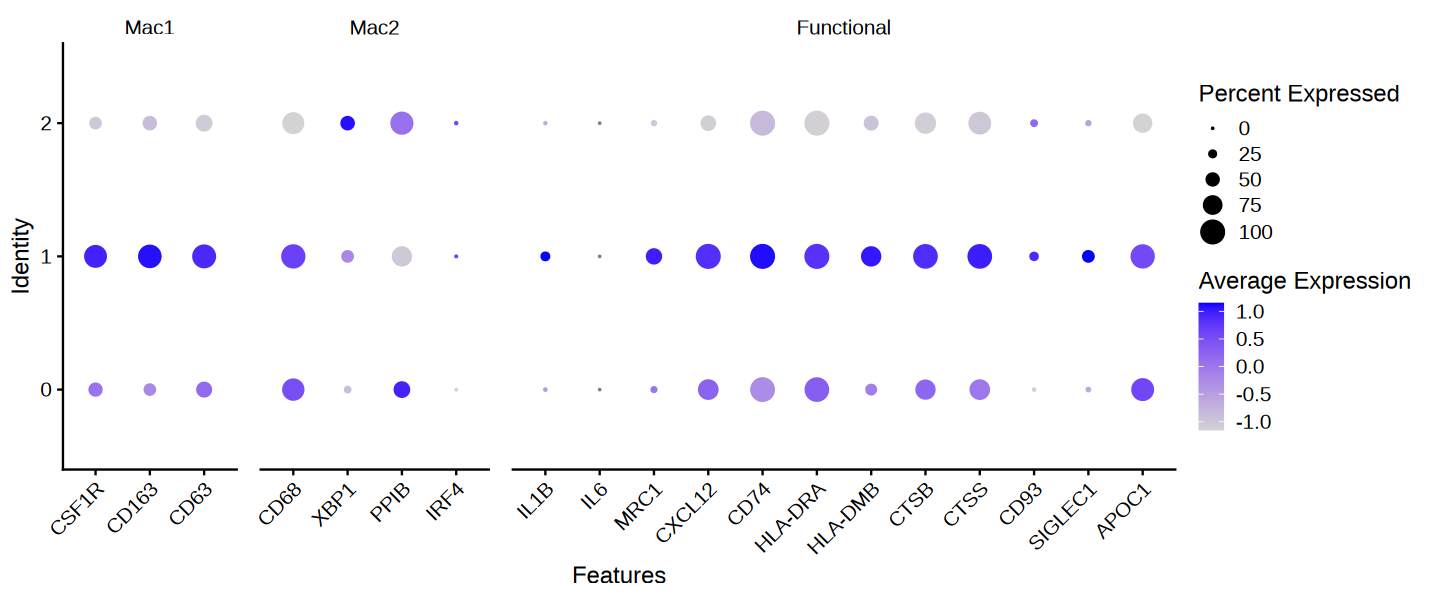

In [72]:
mac_sub_markers <- list(
  "Mac1"         = c("CSF1R", "CD163", "CD63"),
  "Mac2"         = c("CD68", "XBP1", "PPIB", "IRF4"),
  "Functional"   = c("IL1B", "IL6", "MRC1", "CXCL12", "CD74", "HLA-DRA", "HLA-DMB", "CTSB", "CTSS", "CD93", "SIGLEC1", "APOC1")
)

options(repr.plot.width=12, repr.plot.height=5)
DotPlot(mac_seurat, features = mac_sub_markers) + RotatedAxis()

In [73]:
# 人类巨噬细胞4个亚群标记（同格式）
human_mac_sub_markers <- list(
  "Mc-C1" = c("IL1B", "IL6", "S100A", "ANXA1"),
  "Mc-C2" = c("CSF1R", "IL10RA", "MARCO", "CD47", "C1QA"),
  "Mc-C3" = c("HBM", "HBG1", "HBA1", "SOD1", "PRDX2"),
  "Mc-C4" = c("HLA-DRA", "HLA-DRB1", "CD74", "CD1D", "CIITA")
)

Warning message:
“The following requested variables were not found: S100A, HBM, HBG1”
Warning message:
“Scaling data with a low number of groups may produce misleading results”


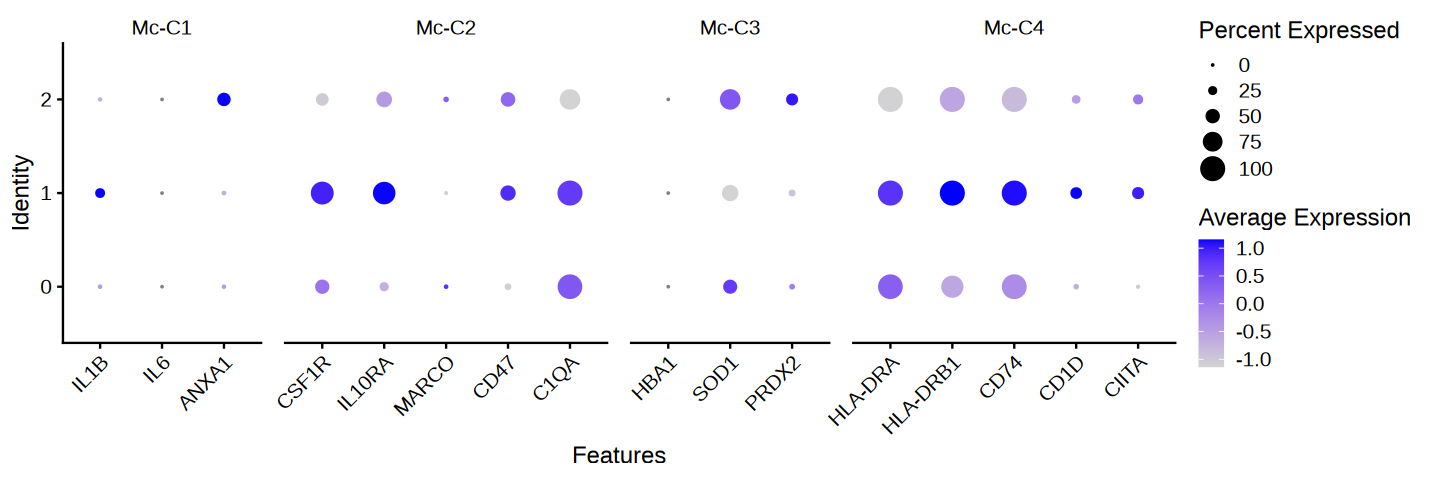

In [78]:
options(repr.plot.width=12, repr.plot.height=4)
DotPlot(mac_seurat, features = human_mac_sub_markers) + RotatedAxis()

Warning message:
“Scaling data with a low number of groups may produce misleading results”


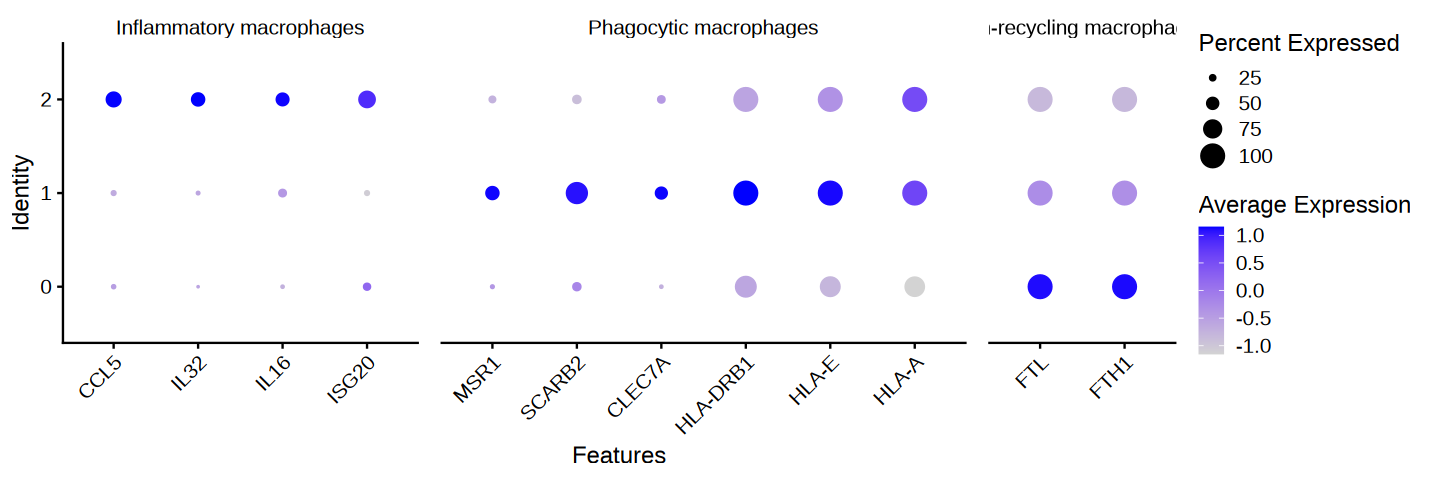

In [81]:
human_mac_3sub_markers <- list(
  "Inflammatory macrophages"  = c("CCL5", "IL32", "IL16", "ISG20"),
  "Phagocytic macrophages"    = c("MSR1", "SCARB2", "CLEC7A", "HLA-DRB1", "HLA-E", "HLA-A"),
  "Iron-recycling macrophages" = c("FTL", "FTH1")
)

options(repr.plot.width=12, repr.plot.height=4)
DotPlot(mac_seurat, features = human_mac_3sub_markers) + RotatedAxis()

In [86]:
Idents(mac_seurat) <- mac_seurat$seurat_clusters

In [87]:
new.cluster.ids <- c(
  "0" = "Iron-recycling macrophages",                
  "1" = "Phagocytic macrophages",          
  "2" = "Inflammatory macrophages"     
)

mac_seurat <- RenameIdents(mac_seurat, new.cluster.ids)
mac_seurat$sub_cell_type <- Idents(mac_seurat)

table(mac_seurat$sub_cell_type)


Iron-recycling macrophages     Phagocytic macrophages 
                       113                         59 
  Inflammatory macrophages 
                        57 

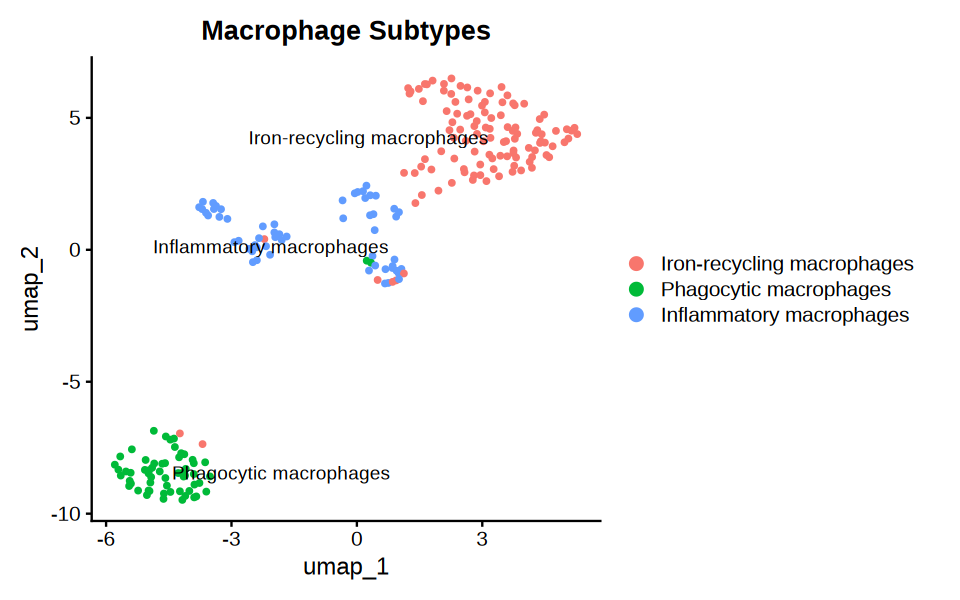

In [90]:
options(repr.plot.width=8, repr.plot.height=5)
DimPlot(mac_seurat, label = TRUE, repel = TRUE, group.by = "sub_cell_type") +
  ggtitle("Macrophage Subtypes")